In [2]:
import torch
import einops
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch import Tensor

In [3]:
def p4m_reflect_action(x: Tensor, dim : int = 2) -> Tensor:
    if x.shape[dim] == 4:
        idx = torch.tensor([0, 3, 2, 1], device=x.device)
        x = x.index_select(dim, idx)
    else:
        raise ValueError(f"x.shape[dim] must be 4, got {x.shape[dim]}")
    return x

In [ ]:
# Test for p4m_reflect_action

# Create a dummy input tensor of shape (batch, channel, group, height, width)
x = torch.arange(2*3*4*5*5).float().reshape(2, 3, 4, 5, 5)
print("Original group axis:\n", x[0, 0, :, 0, 0])

# Apply p4m_reflect_action over group axis (dim=2)
x_reflected = p4m_reflect_action(x.clone(), dim=2)
print("Reflected group axis:\n", x_reflected[0, 0, :, 0, 0])

print("\nShould reverse entries: [0, 3, 2, 1]")
print("Original:", x[0, 0, :, 0, 0].tolist())
print("Reflected:", x_reflected[0, 0, :, 0, 0].tolist())

# Visual test for a simple case
x_simple = torch.tensor(
    [[1, 2, 3, 4]]  # shape (1, 4)
)
res = p4m_reflect_action(x_simple, dim=1)
print("Simple case reflect:", res)

Original group axis:
 tensor([ 0., 25., 50., 75.])
Reflected group axis:
 tensor([ 0., 75., 50., 25.])

Should reverse entries: [0, 3, 2, 1]
Original: [0.0, 25.0, 50.0, 75.0]
Reflected: [0.0, 75.0, 50.0, 25.0]
torch.Size([1, 4])
Simple case reflect: tensor([[1, 4, 3, 2]])


## CIFAR + `P4Z2ConvBlock` rotation demo

The cells below load a single CIFAR-10 image, apply a `P4Z2ConvBlock`, rotate the image by 90 degrees, and compare the two outputs.

For a `P4Z2ConvBlock`, rotating the input should rotate the output spatially and also roll the size-4 group axis.

In [31]:
import pickle
import tarfile
import urllib.request
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    return start


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DOWNLOADS = REPO_ROOT / "downloads"
DOWNLOADS.mkdir(exist_ok=True)

from p4mresnet import P4MZ2ConvBlock, p4m_reflect_action
from p4resnet import P4Z2ConvBlock

In [32]:
def ensure_cifar10(downloads_dir: Path) -> Path:
    cifar_root = downloads_dir / "cifar-10-batches-py"
    required = [cifar_root / f"data_batch_{idx}" for idx in range(1, 6)]
    required += [cifar_root / "test_batch", cifar_root / "batches.meta"]
    if all(path.exists() for path in required):
        return cifar_root

    archive_path = downloads_dir / "cifar-10-python.tar.gz"
    if not archive_path.exists():
        urllib.request.urlretrieve(
            "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
            archive_path,
        )

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(downloads_dir)
    return cifar_root


def load_cifar_batch(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with path.open("rb") as handle:
        batch = pickle.load(handle, encoding="bytes")
    images = np.asarray(batch[b"data"], dtype=np.uint8).reshape(-1, 3, 32, 32)
    labels = np.asarray(batch[b"labels"], dtype=np.int64)
    return images, labels


def load_cifar10_test(downloads_dir: Path) -> tuple[np.ndarray, np.ndarray, list[str]]:
    cifar_root = ensure_cifar10(downloads_dir)
    test_images, test_labels = load_cifar_batch(cifar_root / "test_batch")
    with (cifar_root / "batches.meta").open("rb") as handle:
        meta = pickle.load(handle, encoding="bytes")
    class_names = [name.decode("utf-8") for name in meta[b"label_names"]]
    return test_images, test_labels, class_names


cifar_images, cifar_labels, class_names = load_cifar10_test(DOWNLOADS)
print(cifar_images.shape, cifar_labels.shape)

(10000, 3, 32, 32) (10000,)


/tmp/ipykernel_68206/4002702477.py:22: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(handle, encoding="bytes")


In [33]:
torch.manual_seed(1)


def rotate_z2(x: torch.Tensor, k: int) -> torch.Tensor:
    return torch.rot90(x, k=k, dims=(-2, -1))


def act_p4(x: torch.Tensor, k: int) -> torch.Tensor:
    x = torch.rot90(x, k=k, dims=(-2, -1))
    return torch.roll(x, shifts=k, dims=2)


image_index = 20
image = torch.tensor(cifar_images[image_index], dtype=torch.float32) / 255.0
label = class_names[int(cifar_labels[image_index])]

x = image.unsqueeze(0)
x_rot = rotate_z2(x, 1)

block = P4Z2ConvBlock(
    in_channels=3,
    out_channels=4,
    kernel_size=3,
    stride=1,
    use_batch_norm=False,
    activation=None,
).eval()

with torch.no_grad():
    y = block(x)
    y_rot_input = block(x_rot)
    y_expected = act_p4(y, 1)

print(f"label: {label}")
print("x shape:", tuple(x.shape))
print("y shape:", tuple(y.shape))
print("max |f(rot x) - rot f(x)|:", float((y_rot_input - y_expected).abs().max()))
print("sanity check", float((y_rot_input - y).abs().max()))

label: horse
x shape: (1, 3, 32, 32)
y shape: (1, 4, 4, 32, 32)
max |f(rot x) - rot f(x)|: 9.5367431640625e-07
sanity check 2.0172245502471924


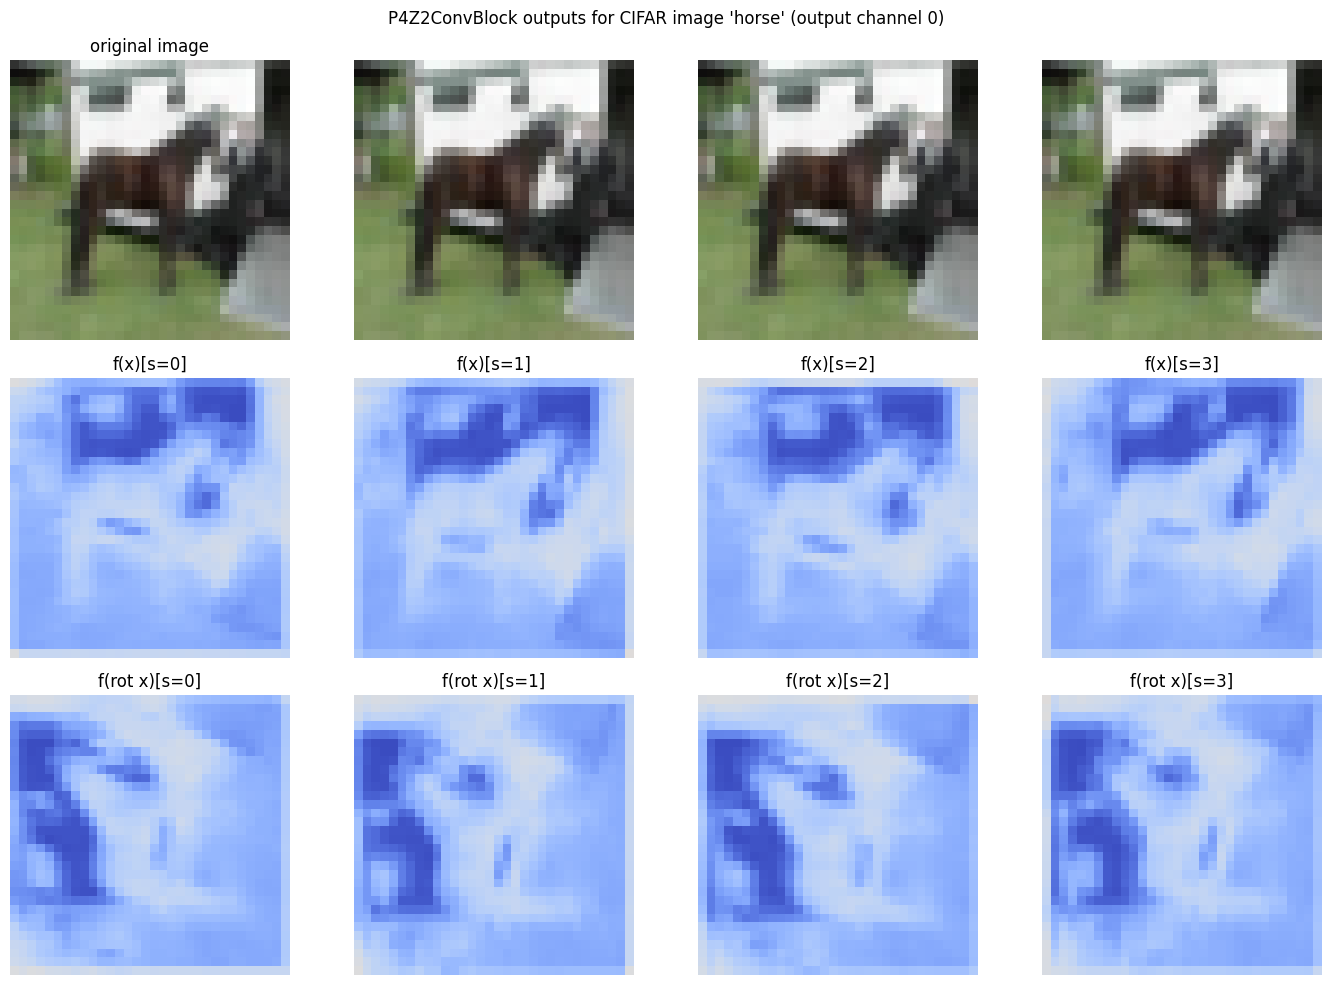

In [34]:
from matplotlib.colors import TwoSlopeNorm


channel_index = 0
output = y[0, channel_index].cpu().numpy()
output_rot_input = y_rot_input[0, channel_index].cpu().numpy()
output_expected = y_expected[0, channel_index].cpu().numpy()

vmax = np.max(np.abs(np.stack([output, output_rot_input, output_expected])))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle(f"P4Z2ConvBlock outputs for CIFAR image '{label}' (output channel {channel_index})")

for s in range(4):
    axes[0, s].imshow(np.transpose(image.numpy(), (1, 2, 0)))
    axes[0, s].set_title("original image" if s == 0 else "")
    axes[0, s].axis("off")

for s in range(4):
    axes[1, s].imshow(output[s], cmap="coolwarm", norm=norm)
    axes[1, s].set_title(f"f(x)[s={s}]")
    axes[1, s].axis("off")

for s in range(4):
    axes[2, s].imshow(output_rot_input[s], cmap="coolwarm", norm=norm)
    axes[2, s].set_title(f"f(rot x)[s={s}]")
    axes[2, s].axis("off")

plt.tight_layout()
plt.show()

overall max abs error: 9.53674316e-07
s=0: max abs error = 7.15255737e-07, mean abs error = 8.16471584e-08
s=1: max abs error = 9.53674316e-07, mean abs error = 8.60181899e-08
s=2: max abs error = 7.15255737e-07, mean abs error = 7.25885911e-08
s=3: max abs error = 7.15255737e-07, mean abs error = 8.83837856e-08


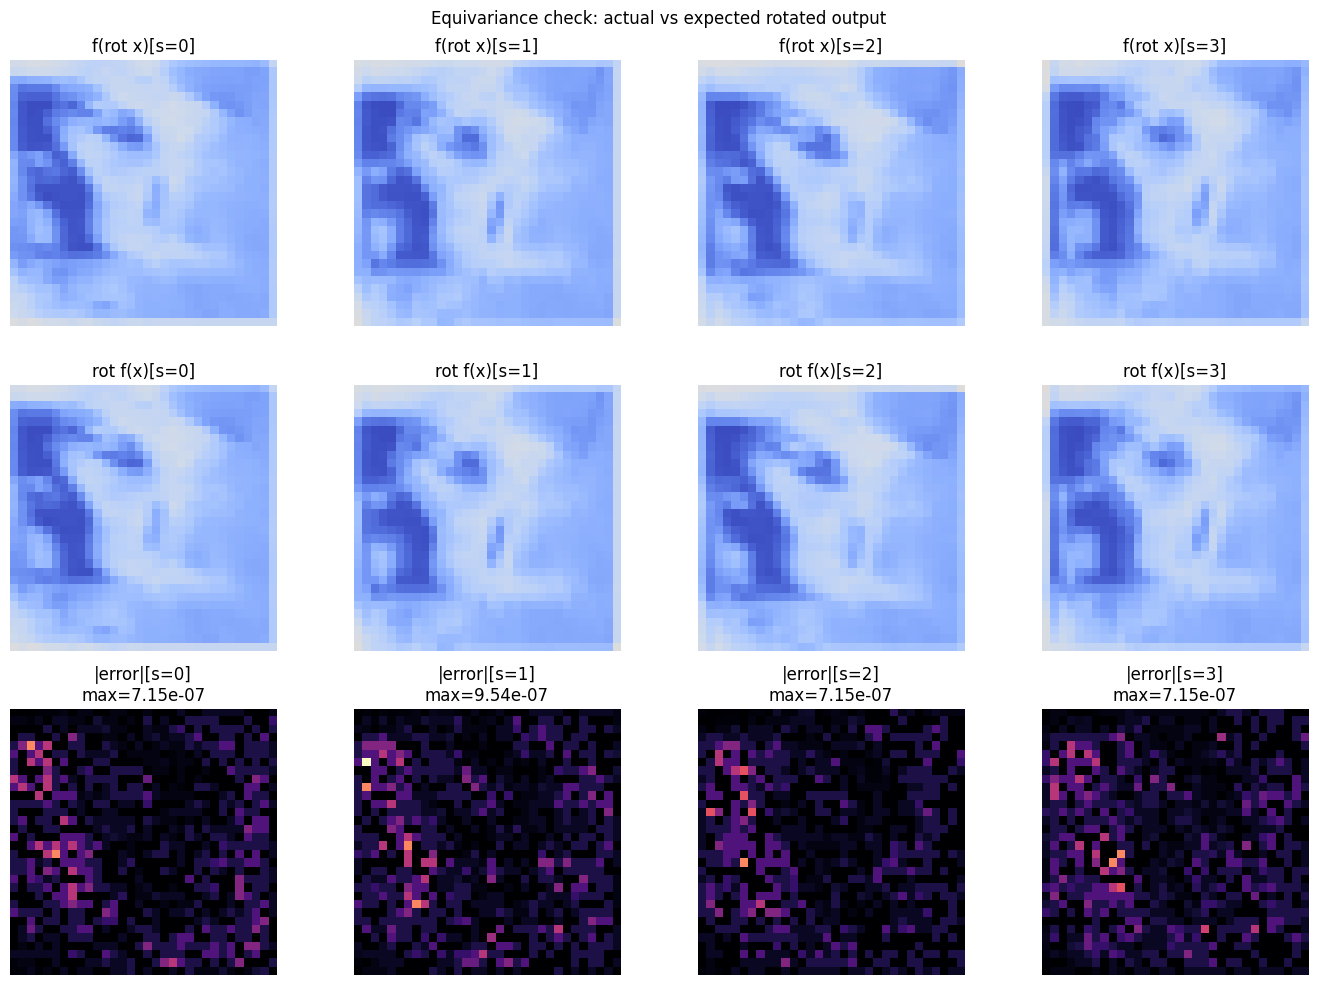

In [35]:
abs_error = np.abs(output_rot_input - output_expected)
overall_max_error = float(abs_error.max())
per_slice_max_error = abs_error.reshape(4, -1).max(axis=1)
per_slice_mean_error = abs_error.reshape(4, -1).mean(axis=1)

print(f"overall max abs error: {overall_max_error:.8e}")
for s in range(4):
    print(
        f"s={s}: max abs error = {per_slice_max_error[s]:.8e}, "
        f"mean abs error = {per_slice_mean_error[s]:.8e}"
    )

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Equivariance check: actual vs expected rotated output")

for s in range(4):
    axes[0, s].imshow(output_rot_input[s], cmap="coolwarm", norm=norm)
    axes[0, s].set_title(f"f(rot x)[s={s}]")
    axes[0, s].axis("off")

for s in range(4):
    axes[1, s].imshow(output_expected[s], cmap="coolwarm", norm=norm)
    axes[1, s].set_title(f"rot f(x)[s={s}]")
    axes[1, s].axis("off")

error_vmax = overall_max_error if overall_max_error > 0 else 1e-12
for s in range(4):
    axes[2, s].imshow(abs_error[s], cmap="magma", vmin=0.0, vmax=error_vmax)
    axes[2, s].set_title(f"|error|[s={s}]\nmax={per_slice_max_error[s]:.2e}")
    axes[2, s].axis("off")

plt.tight_layout()
plt.show()

## CIFAR + `P4MZ2ConvBlock` reflection demo

This section uses a `P4MZ2ConvBlock`, reflects the same CIFAR image horizontally, and checks the `P4M` reflection action on the output.

For `P4M`, reflecting the input should flip the output spatially, permute each size-4 rotation block with `[0, 3, 2, 1]`, and swap the rotation and reflection halves of the group axis.

In [36]:
def reflect_z2(x: torch.Tensor) -> torch.Tensor:
    return torch.flip(x, dims=(-1,))


def act_p4m_reflection(x: torch.Tensor) -> torch.Tensor:
    x = torch.flip(x, dims=(-1,))
    top, bottom = x.split(4, dim=2)
    top = p4m_reflect_action(top, dim=2)
    bottom = p4m_reflect_action(bottom, dim=2)
    return torch.cat([bottom, top], dim=2)


x_reflect = reflect_z2(x)

p4m_block = P4MZ2ConvBlock(
    in_channels=3,
    out_channels=4,
    kernel_size=3,
    stride=1,
    use_batch_norm=False,
    activation=None,
).eval()

with torch.no_grad():
    y_p4m = p4m_block(x)
    y_p4m_reflect_input = p4m_block(x_reflect)
    y_p4m_expected = act_p4m_reflection(y_p4m)

print("x_reflect shape:", tuple(x_reflect.shape))
print("y_p4m shape:", tuple(y_p4m.shape))
print(
    "max |f(reflect x) - reflect f(x)|:",
    float((y_p4m_reflect_input - y_p4m_expected).abs().max()),
)

x_reflect shape: (1, 3, 32, 32)
y_p4m shape: (1, 4, 8, 32, 32)
max |f(reflect x) - reflect f(x)|: 1.430511474609375e-06


overall max abs error (reflection): 3.27825546e-07
s=0: max abs error = 2.38418579e-07, mean abs error = 2.90440596e-08
s=1: max abs error = 2.08616257e-07, mean abs error = 2.92539113e-08
s=2: max abs error = 2.38418579e-07, mean abs error = 3.07268806e-08
s=3: max abs error = 3.27825546e-07, mean abs error = 3.96508426e-08
s=4: max abs error = 1.78813934e-07, mean abs error = 2.78101489e-08
s=5: max abs error = 2.90572643e-07, mean abs error = 4.39688392e-08
s=6: max abs error = 2.19792128e-07, mean abs error = 3.26002407e-08
s=7: max abs error = 1.97440386e-07, mean abs error = 3.00638021e-08


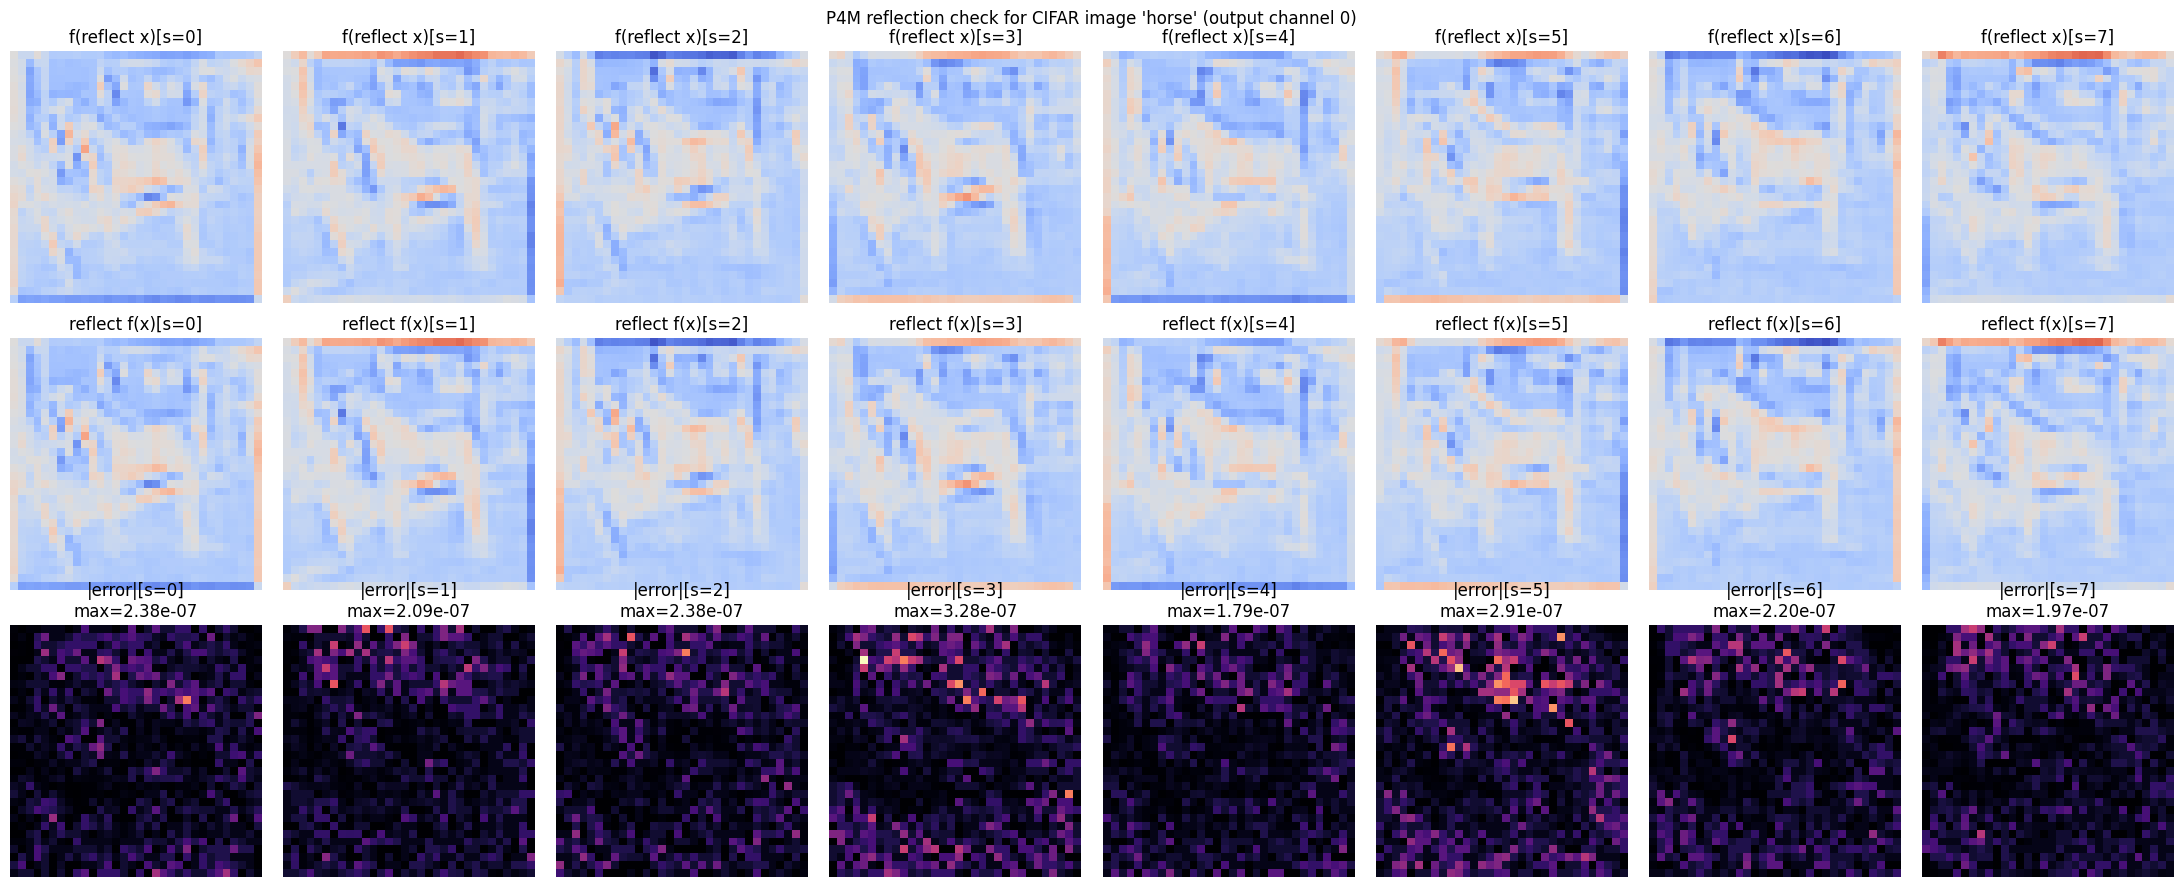

In [37]:
channel_index_p4m = 0
output_p4m_reflect_input = y_p4m_reflect_input[0, channel_index_p4m].cpu().numpy()
output_p4m_expected = y_p4m_expected[0, channel_index_p4m].cpu().numpy()
abs_error_p4m = np.abs(output_p4m_reflect_input - output_p4m_expected)

overall_max_error_p4m = float(abs_error_p4m.max())
per_slice_max_error_p4m = abs_error_p4m.reshape(8, -1).max(axis=1)
per_slice_mean_error_p4m = abs_error_p4m.reshape(8, -1).mean(axis=1)

print(f"overall max abs error (reflection): {overall_max_error_p4m:.8e}")
for s in range(8):
    print(
        f"s={s}: max abs error = {per_slice_max_error_p4m[s]:.8e}, "
        f"mean abs error = {per_slice_mean_error_p4m[s]:.8e}"
    )

vmax_p4m = np.max(np.abs(np.stack([output_p4m_reflect_input, output_p4m_expected])))
norm_p4m = TwoSlopeNorm(vmin=-vmax_p4m, vcenter=0.0, vmax=vmax_p4m)
error_vmax_p4m = overall_max_error_p4m if overall_max_error_p4m > 0 else 1e-12

fig, axes = plt.subplots(3, 8, figsize=(22, 9))
fig.suptitle(
    f"P4M reflection check for CIFAR image '{label}' (output channel {channel_index_p4m})"
)

for s in range(8):
    axes[0, s].imshow(output_p4m_reflect_input[s], cmap="coolwarm", norm=norm_p4m)
    axes[0, s].set_title(f"f(reflect x)[s={s}]")
    axes[0, s].axis("off")

for s in range(8):
    axes[1, s].imshow(output_p4m_expected[s], cmap="coolwarm", norm=norm_p4m)
    axes[1, s].set_title(f"reflect f(x)[s={s}]")
    axes[1, s].axis("off")

for s in range(8):
    axes[2, s].imshow(abs_error_p4m[s], cmap="magma", vmin=0.0, vmax=error_vmax_p4m)
    axes[2, s].set_title(f"|error|[s={s}]\nmax={per_slice_max_error_p4m[s]:.2e}")
    axes[2, s].axis("off")

plt.tight_layout()
plt.show()

## Why a regular `ConvBlock` fails for `P4` and `P4M`

The `P4Z2ConvBlock` and `P4MZ2ConvBlock` are built so that rotating or reflecting the input produces a predictable transformed output.

A standard `ConvBlock` does not tie together rotated or reflected copies of its filters, so in general it is not equivariant to those transformations. The next two cells show that failure directly.

label: horse
max |f(rot x) - rot f(x)| for regular ConvBlock: 0.2924
mean |f(rot x) - rot f(x)| for regular ConvBlock: 0.0551


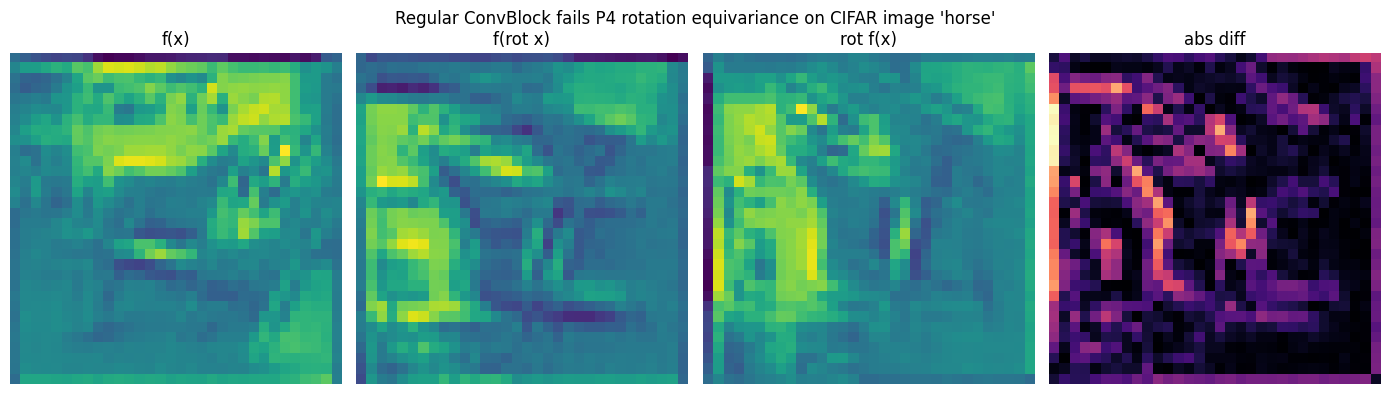

In [38]:
from resnet import ConvBlock


torch.manual_seed(7)


def rotate_z2_local(x: torch.Tensor, k: int) -> torch.Tensor:
    return torch.rot90(x, k=k, dims=(-2, -1))


image_index = 20
image = torch.tensor(cifar_images[image_index], dtype=torch.float32) / 255.0
label = class_names[int(cifar_labels[image_index])]
x = image.unsqueeze(0)

regular_block_p4 = ConvBlock(
    in_channels=3,
    out_channels=1,
    kernel_size=3,
    use_batch_norm=False,
    activation=None,
).eval()

with torch.no_grad():
    y = regular_block_p4(x)
    y_rot_input = regular_block_p4(rotate_z2_local(x, 1))
    y_rot_expected = rotate_z2_local(y, 1)
    rotation_error = (y_rot_input - y_rot_expected).abs()

print(f"label: {label}")
print(f"max |f(rot x) - rot f(x)| for regular ConvBlock: {rotation_error.max().item():.4f}")
print(f"mean |f(rot x) - rot f(x)| for regular ConvBlock: {rotation_error.mean().item():.4f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(y[0, 0].cpu(), cmap="viridis")
axes[0].set_title("f(x)")
axes[1].imshow(y_rot_input[0, 0].cpu(), cmap="viridis")
axes[1].set_title("f(rot x)")
axes[2].imshow(y_rot_expected[0, 0].cpu(), cmap="viridis")
axes[2].set_title("rot f(x)")
axes[3].imshow(rotation_error[0, 0].cpu(), cmap="magma")
axes[3].set_title("abs diff")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Regular ConvBlock fails P4 rotation equivariance on CIFAR image '{label}'")
plt.tight_layout()

label: horse
max |f(reflect x) - reflect f(x)| for regular ConvBlock: 0.5194
mean |f(reflect x) - reflect f(x)| for regular ConvBlock: 0.0794


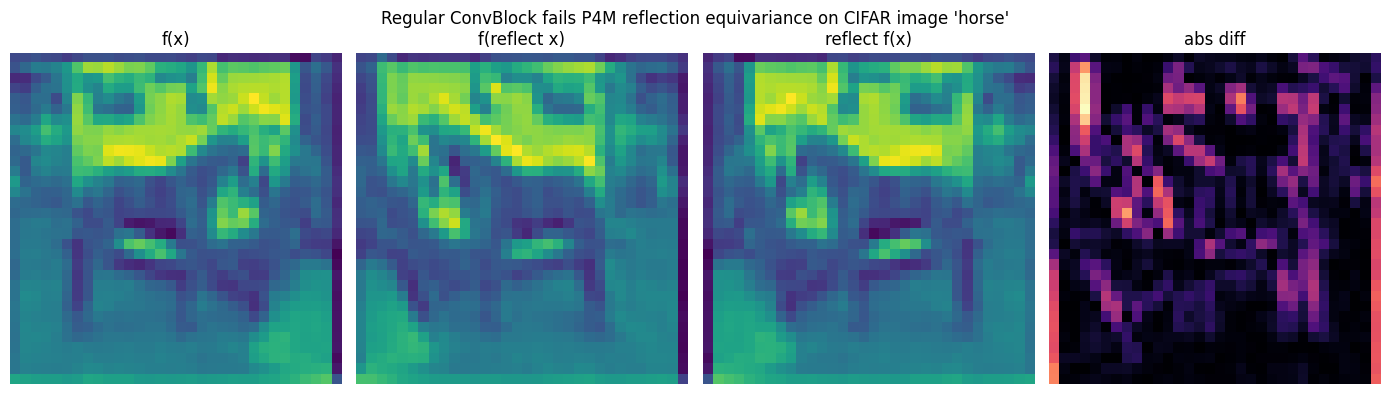

In [39]:
torch.manual_seed(11)


def reflect_z2_local(x: torch.Tensor) -> torch.Tensor:
    return torch.flip(x, dims=(-1,))


image_index = 20
image = torch.tensor(cifar_images[image_index], dtype=torch.float32) / 255.0
label = class_names[int(cifar_labels[image_index])]
x = image.unsqueeze(0)

regular_block_p4m = ConvBlock(
    in_channels=3,
    out_channels=1,
    kernel_size=3,
    use_batch_norm=False,
    activation=None,
).eval()

with torch.no_grad():
    y = regular_block_p4m(x)
    y_ref_input = regular_block_p4m(reflect_z2_local(x))
    y_ref_expected = reflect_z2_local(y)
    reflection_error = (y_ref_input - y_ref_expected).abs()

print(f"label: {label}")
print(f"max |f(reflect x) - reflect f(x)| for regular ConvBlock: {reflection_error.max().item():.4f}")
print(f"mean |f(reflect x) - reflect f(x)| for regular ConvBlock: {reflection_error.mean().item():.4f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(y[0, 0].cpu(), cmap="viridis")
axes[0].set_title("f(x)")
axes[1].imshow(y_ref_input[0, 0].cpu(), cmap="viridis")
axes[1].set_title("f(reflect x)")
axes[2].imshow(y_ref_expected[0, 0].cpu(), cmap="viridis")
axes[2].set_title("reflect f(x)")
axes[3].imshow(reflection_error[0, 0].cpu(), cmap="magma")
axes[3].set_title("abs diff")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Regular ConvBlock fails P4M reflection equivariance on CIFAR image '{label}'")
plt.tight_layout()